# Quasi-Stationary Response Geometry -- a computational companion

*Companion notebook to the paper* `qsd_response_geometry.tex`, *its verification script*
`verify_identities.py` *(Remark 4.8), and the worked fold instance of*
`figures/fold_example.py` *(Example 7.4, Figure 3).*

Fix a finite set $T$ with $|T|=n\ge 2$. The paper studies the **principal spectral
datum** $(\Lambda,\nu)$ -- the decay rate and the quasi-stationary distribution (QSD) --
of a real-analytic family $\theta\mapsto Q(\theta)$ of irreducible Metzler
sub-generators, and develops a closed first-order response calculus describing how
$(\Lambda,\nu)$ responds to $\theta$, together with the canonical geometry that this
response carries. Four classical theories are assembled, as in the paper's abstract:
first, Perron-Frobenius spectral theory (§2); second, invariant-subspace theory and the
group inverse, through which Kato's analytic perturbation theory acts (§3-§4); third,
the Fisher-Rao information geometry of the simplex, pulled back through the QSD map
(§5); fourth, constant-rank analysis and stratification -- the response manifold, its
non-identifiability foliation, and the rank-one divergence of the information metric at
simple folds of a self-consistent constraint (§6, with the worked examples of §7).

This notebook is the numerical companion. For each principal result we state the
theorem under its printed number (occasionally in an equivalent normalized form, marked
where so), explain how the implementation realizes its hypotheses, and verify the
displayed identities by central finite differences against a reproducible family of
irreducible Metzler sub-generators -- the protocol of Remark 4.8. We then reproduce the
self-consistent fold of Example 7.4. Every numerical assertion about the present
computation is recomputed on execution; the paper's reported figures appear only as
comparanda.

**Numbering follows the paper** (in `amsart` style, all environments share one counter
per section, so Theorem 2.3 is followed by Definition 2.4). The paper's private macros
are expanded here with identical typesetting: its $\mathrm{d}$ (the macro `\dd`) is
written $\mathrm{d}$, its $\mathbf{1}$ is the all-ones vector, $\Delta^{\!\circ}$ is the
open probability simplex, and $\mathfrak{s}(Q)$ is the spectral abscissa.

## Conventions and the paper-to-code dictionary

Row vectors act on the left ($\nu Q$), column vectors on the right ($Qh$); the killing
vector is $q:=-Q\mathbf{1}\ge 0$. Throughout, the normalizations
$\nu\mathbf{1}=1$ and $\nu h=1$ are in force.

| paper object | notebook object |
|---|---|
| $Q(\theta)$, irreducible Metzler sub-generator (Definition 2.2) | `make_Q(theta)` |
| principal datum $(\Lambda,\nu,h)$ (Theorem 2.3) | `principal_data(Q)` |
| Riesz projection $P=h\nu$ (Proposition 3.1) | `P` |
| reduced resolvent / group inverse $R=(Q+\Lambda I)^{\#}$ (Definition 3.2) | `R` |
| QSD Jacobian $J=\mathrm{d}\nu$ (Theorem 4.1(c)) | `Jnu_an` |
| information metric $\mathcal G=J^{\top}\operatorname{diag}(1/\nu)\,J$ (Theorem 5.2) | `G_fisher` |
| fold scale $\sigma$, the smallest singular value of $\partial_u F$ (Theorem 6.4); $\sigma=\lvert\partial_u F\rvert$ in the scalar case of Example 7.4 | `sig` |

The only dependencies are `numpy` and (for Figure 3) `matplotlib`; no model code is
imported, so the notebook runs standalone, exactly as `verify_identities.py` does.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.set_printoptions(precision=6, suppress=True)
n = 4                            # |T|, the size of the living class
one = np.ones(n)

## §2 Principal spectral data of irreducible sub-generators

A real $n\times n$ matrix $Q$ is **Metzler** if $Q_{ss'}\ge 0$ for $s\neq s'$; it is a
**sub-generator** (Definition 2.2) if moreover $Q\mathbf{1}\le 0$, and *properly killed*
if the killing vector $q=-Q\mathbf{1}$ is nonzero. A properly killed irreducible
sub-generator admits no stationary distribution on $T$ -- mass leaks to an adjoined
cemetery -- and the relevant long-run object is the quasi-stationary distribution. The
spectral foundation is:

> **Theorem 2.3** (principal datum). *Let $Q\in\mathcal M_{\mathrm{irr}}(T)$ be an
> irreducible, properly killed sub-generator. Then* (i) *the spectral abscissa
> $\mathfrak{s}(Q)$ is a real, algebraically simple eigenvalue of $Q$, strictly dominant
> in real part: $\Re\mu<\mathfrak{s}(Q)$ for every other eigenvalue $\mu$;* (ii) *the
> associated left and right eigenvectors $\nu,h$ may be chosen strictly positive, are
> unique up to positive scaling, and are normalized by $\nu\mathbf{1}=1$, $\nu h=1$;*
> (iii) *writing $\mathfrak{s}(Q)=-\Lambda$, one has $\Lambda>0$ and*
> $$ \Lambda=\nu q=-\,\nu\,Q\,\mathbf{1}. $$

Probabilistically, $\Lambda$ is the exponential decay rate of survival and $\nu$ the
Yaglom limit -- the law of the state conditioned on survival -- but none of the geometry
requires this reading. Proposition 2.6 (analyticity and rigidity) records that on the
regular locus $\Theta_{\mathrm{reg}}$ the datum is real-analytic and the Perron
eigenvalue *cannot* lose simplicity while irreducibility holds, confining spectral
singularities to the boundary -- a short consequence of Perron-Frobenius positivity and
the continuity of spectra, stated because everything downstream consumes it.

**Implementation.** `make_Q` realizes the hypotheses by construction: the off-diagonal
block is the entrywise exponential of a fixed base log-rate matrix perturbed linearly in
$\theta$ -- hence strictly positive, so $Q(\theta)$ is Metzler and irreducible -- and
killing acts out of the single state $s_0=0$ with a rate depending smoothly on $\theta$,
so the family is real-analytic and properly killed on the region $\sum_j\theta_j>-7$,
in particular near the operating point $\theta_0$ used throughout. Remark 4.8's check
runs this protocol on randomly generated families at generic operating points; here the
base is fixed deterministically so that every run reproduces exactly -- the same family
as `verify_identities.py`.

In [2]:
def make_Q(theta):
    # A real-analytic family of irreducible, properly killed Metzler sub-generators
    # (Definition 2.2): exp(.) makes every off-diagonal entry strictly positive
    # (irreducibility); killing q acts out of state 0 only and depends smoothly on theta.
    p = len(theta)
    base = np.array([[ 0.0,  0.3, -0.2,  0.1],
                     [ 0.2,  0.0,  0.4, -0.1],
                     [-0.3,  0.1,  0.0,  0.5],
                     [ 0.25,-0.2,  0.15, 0.0]])
    L = base.copy()
    for j in range(p):                       # parameter j enters two off-diagonal log-rates
        Cj = np.zeros((n, n))
        Cj[j % n, (j + 1) % n] = 1.0
        Cj[(j + 2) % n, (j + 3) % n] = 0.5
        L = L + theta[j] * Cj
    Off = np.exp(L)
    np.fill_diagonal(Off, 0.0)
    Q = Off.copy()
    kill = np.zeros(n)
    kill[0] = 0.7 + 0.1 * np.sum(theta)       # q != 0: properly killed
    np.fill_diagonal(Q, -(Off.sum(axis=1) + kill))
    return Q

theta0 = np.array([0.10, -0.05, 0.08])        # the operating point used throughout
Q0 = make_Q(theta0)
q0 = -(Q0 @ one) + 0.0                        # +0.0 normalizes IEEE signed zeros
assert np.all(q0 >= -1e-12) and q0.max() > 0  # properly killed: q >= 0, q != 0
print("Q(theta0) =\n", Q0)
print("\nkilling vector q = -Q 1 =", q0, " (>= 0, nonzero: properly killed)")

Q(theta0) =
 [[-4.189609  1.552707  0.818731  1.105171]
 [ 1.221403 -3.545308  1.419068  0.904837]
 [ 0.740818  1.105171 -3.7236    1.877611]
 [ 1.252323  0.818731  1.161834 -3.232888]]

killing vector q = -Q 1 = [0.713 0.    0.    0.   ]  (>= 0, nonzero: properly killed)


The principal datum is extracted from the dominant eigenpairs of $Q$ and $Q^{\top}$
(largest real part), normalized as in Theorem 2.3(ii). The reduced resolvent $R$ is
computed by the projection formula of Proposition 3.1 / Lemma A.1,
$R=(A+P)^{-1}(I-P)$ with $A=Q+\Lambda I$, which is exact for an index-one $A$. The
output verifies Theorem 2.3(i)-(iii) at $\theta_0$.

In [3]:
def principal_data(Q):
    # Principal datum (Lambda, nu, h) of Theorem 2.3, normalized nu.1 = 1, nu.h = 1,
    # together with the Riesz projection P = h nu and the reduced resolvent
    # R = (Q + Lambda I)^# computed via the projection formula of Prop. 3.1 / Lemma A.1.
    n = Q.shape[0]
    w, vr = np.linalg.eig(Q)
    k = int(np.argmax(w.real)); Lam = -w[k].real; h = vr[:, k].real
    wl, vl = np.linalg.eig(Q.T)
    kl = int(np.argmax(wl.real)); nu = vl[:, kl].real
    if nu.sum() < 0: nu = -nu
    nu = nu / nu.sum()                        # nu.1 = 1
    if h @ nu < 0: h = -h
    h = h / (nu @ h)                          # nu.h = 1
    A = Q + Lam * np.eye(n)                    # index-1: ker = span(h), coker = span(nu)
    P = np.outer(h, nu)
    R = np.linalg.solve(A + P, np.eye(n) - P)
    return Lam, nu, h, R, P

Lam0, nu0, h0, R0, P0 = principal_data(Q0)

print("Theorem 2.3 at theta0:")
print("  (iii) Lambda > 0          :", Lam0)
print("  (ii)  nu > 0, h > 0       :", np.all(nu0 > 0), np.all(h0 > 0))
print("  (i)   |nu Q + Lambda nu|  :", np.max(np.abs(nu0 @ Q0 + Lam0 * nu0)))
print("        |Q h + Lambda h|    :", np.max(np.abs(Q0 @ h0 + Lam0 * h0)))
print("  (ii)  nu.1, nu.h          :", nu0 @ one, ",", nu0 @ h0)
print("  (iii) Lambda = nu q       :", Lam0, "=", nu0 @ (-(Q0 @ one)))

Theorem 2.3 at theta0:
  (iii) Lambda > 0          : 0.15094193642114195
  (ii)  nu > 0, h > 0       : True True
  (i)   |nu Q + Lambda nu|  : 3.95516952522712e-16
        |Q h + Lambda h|    : 1.9984014443252818e-15
  (ii)  nu.1, nu.h          : 1.0 , 0.9999999999999999
  (iii) Lambda = nu q       : 0.15094193642114195 = 0.15094193642114276


## §3 Invariant subspaces and the reduced resolvent

The simplicity of $-\Lambda$ furnishes a canonical pair of complementary $Q$-invariant
subspaces,
$$ \mathbb R^{T}=\operatorname{Im}P\oplus\ker P,\qquad P=h\nu,\quad P^{2}=P, $$
and the whole response calculus of §4 is the differential geometry of how these
subspaces rotate with $\theta$.

> **Proposition 3.1** (spectral splitting and group inverse). *With $A=Q+\Lambda I$, the
> reduced resolvent $R=A^{\#}$ -- the group inverse of $A$, equivalently
> (Definition 3.2) the inverse of $A$ on $\ker P$ extended by zero on the Perron line --
> satisfies the annihilation identities*
> $$ AR=RA=I-P,\qquad Rh=0,\qquad \nu R=0,\qquad RP=PR=0. $$

$R$ is the inverse of the subdominant block (the block picture of Remark 3.3) and, in
the paper's phrase, "the single object coupling the two channels" (Remark 4.2): it
carries the response of $\nu$ and $P$, while $\Lambda$ responds through the eigenpair
alone. The identities are verified at machine precision at $\theta_0$:

In [4]:
A0 = Q0 + Lam0 * np.eye(n)
print("Proposition 3.1 (annihilation identities; expect ~1e-16):")
print("  |A R - (I - P)| :", np.max(np.abs(A0 @ R0 - (np.eye(n) - P0))))
print("  |R A - (I - P)| :", np.max(np.abs(R0 @ A0 - (np.eye(n) - P0))))
print("  |R h|           :", np.max(np.abs(R0 @ h0)))
print("  |nu R|          :", np.max(np.abs(nu0 @ R0)))
print("  |R P|, |P R|    :", np.max(np.abs(R0 @ P0)), ",", np.max(np.abs(P0 @ R0)))

Proposition 3.1 (annihilation identities; expect ~1e-16):
  |A R - (I - P)| : 2.220446049250313e-16
  |R A - (I - P)| : 5.551115123125783e-16
  |R h|           : 1.880436697331205e-16
  |nu R|          : 1.0672803834298913e-16
  |R P|, |P R|    : 5.932607067960574e-17 , 1.0704838234000707e-16


## §4 The response calculus

> **Theorem 4.1** (first-order response). *Let $\theta\mapsto Q(\theta)$ be a
> real-analytic family in $\mathcal M_{\mathrm{irr}}(T)$ and write
> $Q_j:=\partial Q/\partial\theta_j$. Then on $\Theta_{\mathrm{reg}}$, with the
> normalizations $\nu\mathbf{1}=1$, $\nu h=1$:*
> $$ \text{(a)}\qquad \partial_j P=-\bigl(R\,Q_j\,P+P\,Q_j\,R\bigr), $$
> $$ \text{(b)}\qquad \partial_j \Lambda=-\,\nu\,Q_j\,h \qquad\text{(Hellmann-Feynman)}, $$
> $$ \text{(c)}\qquad \partial_j \nu=-\,\nu\,Q_j\,R+c_j\,\nu,\qquad c_j=\nu\,Q_j\,R\,\mathbf{1}. $$

The printed statement also contains (d), the right-eigenvector response
$\partial_j h=-R\,Q_j\,h+d_j\,h$ with the scalar $d_j$ fixed by the normalization
$\nu h=1$, together with a boundedness clause; differentiating $\nu h=1$ and using
$\nu R=0$, $Rh=0$ gives $d_j=-(\partial_j\nu)\,h=-c_j$. We verify (a)-(d) below.

Note the division of labor: (b) uses only the eigenpair, while (a), (c), and (d) are
carried by the reduced resolvent. In (c), $-\nu Q_jR$ is the *intrinsic* part and the
scalar correction $c_j\nu$ is determined by the normalization $\nu\mathbf{1}=1$ -- it
returns the derivative to the simplex tangent space, $\partial_j\nu\cdot\mathbf{1}=0$
(Remark 4.3).

**Verification protocol (Remark 4.8).** Each displayed identity is compared with a
central finite difference of the spectral solver itself; the paper reports relative
agreement $\le 10^{-8}$ at first order and $\le 10^{-7}$ at second order. Since
$Q(\theta)$ is nonlinear in $\theta$ (through the exponential and the
$\theta$-dependent killing), $Q_j$ is likewise obtained by differencing.

In [5]:
def grad_fd(f, theta, eps=1e-6):
    # Central finite-difference Jacobian of a vector- or scalar-valued f(theta).
    p = len(theta); f0 = np.atleast_1d(f(theta)); J = np.zeros((len(f0), p))
    for j in range(p):
        tp = theta.copy(); tp[j] += eps
        tm = theta.copy(); tm[j] -= eps
        J[:, j] = (np.atleast_1d(f(tp)) - np.atleast_1d(f(tm))) / (2 * eps)
    return J if len(f0) > 1 else J[0]

p = len(theta0)
dQ = grad_fd(lambda t: make_Q(t).reshape(-1), theta0).reshape(n, n, p)   # Q_j

# Theorem 4.1(b): Hellmann-Feynman
dLam_fd = grad_fd(lambda t: principal_data(make_Q(t))[0], theta0)
dLam_an = np.array([-nu0 @ dQ[:, :, j] @ h0 for j in range(p)])
print("Theorem 4.1(b)  d Lambda  max|FD - analytic| :", np.max(np.abs(dLam_fd - dLam_an)))

# Theorem 4.1(c): QSD response through the reduced resolvent
Jnu_fd = grad_fd(lambda t: principal_data(make_Q(t))[1], theta0)        # n x p
Jnu_an = np.zeros((n, p))
for j in range(p):
    cj = nu0 @ dQ[:, :, j] @ R0 @ one
    Jnu_an[:, j] = -nu0 @ dQ[:, :, j] @ R0 + cj * nu0
print("Theorem 4.1(c)  d nu      max|FD - analytic| :", np.max(np.abs(Jnu_fd - Jnu_an)))
print("Remark 4.3      simplex tangency, max|sum_s (d nu)_s| :", np.max(np.abs(Jnu_an.sum(axis=0))))

# Theorem 4.1(a): projection derivative
JP_fd = grad_fd(lambda t: principal_data(make_Q(t))[4].reshape(-1), theta0).reshape(n, n, p)
errP = max(np.max(np.abs(JP_fd[:, :, j] - (-(R0 @ dQ[:, :, j] @ P0 + P0 @ dQ[:, :, j] @ R0))))
           for j in range(p))
print("Theorem 4.1(a)  d P       max|FD - analytic| :", errP)

# Theorem 4.1(d): right-eigenvector response, d_j = -c_j (from nu.h = 1 and R h = 0)
Jh_fd = grad_fd(lambda t: principal_data(make_Q(t))[2], theta0)         # n x p
Jh_an = np.zeros((n, p))
for j in range(p):
    cj = nu0 @ dQ[:, :, j] @ R0 @ one
    Jh_an[:, j] = -R0 @ dQ[:, :, j] @ h0 - cj * h0
print("Theorem 4.1(d)  d h       max|FD - analytic| :", np.max(np.abs(Jh_fd - Jh_an)))

Theorem 4.1(b)  d Lambda  max|FD - analytic| : 5.607077606037403e-10
Theorem 4.1(c)  d nu      max|FD - analytic| : 9.481582186054993e-11
Remark 4.3      simplex tangency, max|sum_s (d nu)_s| : 1.3877787807814457e-17
Theorem 4.1(a)  d P       max|FD - analytic| : 1.8275372881682017e-10
Theorem 4.1(d)  d h       max|FD - analytic| : 4.364719488614277e-10


### §4.2 Second-order response

> **Proposition 4.4** (curvature of the decay rate). *With $\lambda_{*}=-\Lambda$ the
> Perron eigenvalue,*
> $$ \partial_i\partial_j\lambda_{*}=\nu\,(\partial_i\partial_jQ)\,h-\nu\,Q_i\,R\,Q_j\,h-\nu\,Q_j\,R\,Q_i\,h. $$

The reduced resolvent re-enters at second order. (Remark 4.5 cautions that this Hessian
is not sign-definite: $\Lambda$ is neither convex nor concave in general.) Both sides
are differenced at step $10^{-4}$, so agreement at $\sim10^{-7}$-$10^{-8}$ is the
expected finite-difference floor (Remark 4.8).

In [6]:
def lam_star(t):
    w = np.linalg.eigvals(make_Q(t)); return float(w[np.argmax(w.real)].real)   # = -Lambda

e = 1e-4
def d2(f, i, j):
    tpp = theta0.copy(); tpp[i] += e; tpp[j] += e
    tpm = theta0.copy(); tpm[i] += e; tpm[j] -= e
    tmp = theta0.copy(); tmp[i] -= e; tmp[j] += e
    tmm = theta0.copy(); tmm[i] -= e; tmm[j] -= e
    return (f(tpp) - f(tpm) - f(tmp) + f(tmm)) / (4 * e * e)

Hl_fd = np.array([[d2(lam_star, i, j) for j in range(p)] for i in range(p)])
d2Q = lambda i, j: d2(lambda t: make_Q(t), i, j)
Hl_an = np.array([[nu0 @ d2Q(i, j) @ h0
                   - nu0 @ dQ[:, :, i] @ R0 @ dQ[:, :, j] @ h0
                   - nu0 @ dQ[:, :, j] @ R0 @ dQ[:, :, i] @ h0 for j in range(p)] for i in range(p)])
print("Proposition 4.4  Hess(lambda_*)  max|FD - analytic| :", np.max(np.abs(Hl_fd - Hl_an)))

Proposition 4.4  Hess(lambda_*)  max|FD - analytic| : 3.427787754334277e-08


### §4.3 The conservative limit

We now make precise the sense in which the calculus reduces, as the killing is switched
off, to the classical group-inverse / fundamental-matrix sensitivity theory of
stationary Markov chains (Schweitzer, Meyer, Golub-Meyer).

> **Theorem 4.6** (no-killing limit). *Suppose $q(\theta)\to 0$ along a path on which
> $Q\to Q_0$, a conservative irreducible generator. Then $\Lambda\to 0$,
> $h\to\mathbf{1}$, $\nu\to\pi$ -- the stationary distribution of $Q_0$ -- and the reduced
> resolvent converges to the group inverse of $Q_0$ itself,*
> $$ R\to Q_0^{\#}=-Z,\qquad Z=(\mathbf{1}\pi-Q_0)^{-1}-\mathbf{1}\pi $$
> *($Z$ the fundamental matrix), and Theorem 4.1(c) becomes the stationary response $\partial_j\pi=-\,\pi\,Q_j\,Q_0^{\#}=+\,\pi\,Q_j\,Z$.*

The positive sign is fixed by Remark 4.7 on the two-state chain (worked in closed form
as Example 7.1): with rates $a\colon 1\to 2$ and $b\colon 2\to 1$, $\pi_1=b/(a+b)$, so
$\partial\pi_1/\partial a=-b/(a+b)^{2}$, which the response formula must (and does)
reproduce. We evaluate at the conservative endpoint $q\equiv 0$, which the theorem's
limit subsumes.

In [7]:
def make_Qcons(theta):
    # The same family with the killing removed (q = 0): a conservative irreducible
    # generator, realizing the hypotheses of Theorem 4.6.
    base = np.array([[ 0.0,  0.3, -0.2,  0.1],
                     [ 0.2,  0.0,  0.4, -0.1],
                     [-0.3,  0.1,  0.0,  0.5],
                     [ 0.25,-0.2,  0.15, 0.0]])
    L = base.copy()
    for j in range(len(theta)):
        Cj = np.zeros((n, n)); Cj[j % n, (j + 1) % n] = 1.0; Cj[(j + 2) % n, (j + 3) % n] = 0.5
        L = L + theta[j] * Cj
    Off = np.exp(L); np.fill_diagonal(Off, 0.0)
    Q = Off.copy(); np.fill_diagonal(Q, -Off.sum(axis=1))     # row sums 0
    return Q

Qc = make_Qcons(theta0)
Lamc, pic, hc, Rc, Pc = principal_data(Qc)
Z = np.linalg.inv(np.outer(one, pic) - Qc) - np.outer(one, pic)   # fundamental matrix
print("Theorem 4.6 (conservative limit):")
print("  Lambda = 0          :", Lamc)
print("  h = 1, max|h - 1|   :", np.max(np.abs(hc - one)))
print("  pi Q = 0, max|pi Q| :", np.max(np.abs(pic @ Qc)))
print("  R = Q^# = -Z        : max|R + Z| =", np.max(np.abs(Rc + Z)))

dQc = grad_fd(lambda t: make_Qcons(t).reshape(-1), theta0).reshape(n, n, p)
Jpi_fd = grad_fd(lambda t: principal_data(make_Qcons(t))[1], theta0)
Jpi_an = np.column_stack([-pic @ dQc[:, :, j] @ Rc for j in range(p)])     # = +pi Q_j Z
print("  d pi  max|FD - (-pi Q_j Q^#)| :", np.max(np.abs(Jpi_fd - Jpi_an)))

# Remark 4.7 / Example 7.1: the closed-form two-state sign check
a, b = 1.0, 1.0
Q2 = lambda ab: np.array([[-ab[0], ab[0]], [ab[1], -ab[1]]])
def pi1(ab):
    return principal_data(Q2(ab))[1][0]
dpi1_da_fd = (pi1([a + 1e-6, b]) - pi1([a - 1e-6, b])) / 2e-6
print("Remark 4.7 (two-state sign): d pi_1/d a = -b/(a+b)^2 =", -b / (a + b) ** 2,
      "; finite difference =", dpi1_da_fd)

Theorem 4.6 (conservative limit):
  Lambda = 0          : -0.0
  h = 1, max|h - 1|   : 6.661338147750939e-16
  pi Q = 0, max|pi Q| : 6.245422619212677e-16
  R = Q^# = -Z        : max|R + Z| = 3.3306690738754696e-16
  d pi  max|FD - (-pi Q_j Q^#)| : 5.95870019992617e-11
Remark 4.7 (two-state sign): d pi_1/d a = -b/(a+b)^2 = -0.25 ; finite difference = -0.24999999997943334


## §5 The information geometry of the response map

Write $J=\mathrm{d}\nu$ for the QSD Jacobian, an $n\times p$ matrix whose columns are
tangent to the simplex.

> **Theorem 5.2** (information metric of the QSD family). *The QSD map
> $\Phi:\Theta_{\mathrm{reg}}\to\Delta^{\!\circ}$ pulls the Fisher-Rao metric of the open
> simplex back to the Fisher information metric of the family $\{\nu_\theta\}$:*
> $$ \mathcal G=J^{\top}\operatorname{diag}(1/\nu)\,J=\operatorname{Hess}_{\theta'}\,D_{\mathrm{KL}}\bigl(\nu(\theta')\,\Vert\,\nu(\theta)\bigr)\Big|_{\theta'=\theta},\qquad \mathcal G\succeq 0,\qquad \ker\mathcal G=\ker J=\ker\mathrm{d}\Phi. $$

Operationally (Remark 5.3): $\{\nu_\theta\}$ is the model in which one observes the
location of the chain conditioned on survival; $\mathcal G_{ij}$ is the Fisher
information a single such observation carries about $\theta$, and $\ker\mathcal G$ the
directions of $\theta$ that no amount of such data can resolve. On constant-rank strata
these kernels integrate to the **non-identifiability foliation** (Theorem 6.1;
Remark 6.2 calls this the "identifiability dictionary"). The construction is
coordinate-free -- $\mathcal G$ transforms as a $(0,2)$-tensor, so its rank and kernel
are intrinsic (Proposition 5.4).

At the operating point $\theta_0$ the computed (numerical) rank is full and the kernel
trivial, as reported below. *Exact* kernel directions arise from rate symmetries, and
§7.2 exhibits one in closed form.

In [8]:
G_fisher = Jnu_an.T @ np.diag(1.0 / nu0) @ Jnu_an

def KL(aa, bb): return float(np.sum(aa * np.log(aa / bb)))
H = np.zeros((p, p))
for i in range(p):
    for j in range(p):
        H[i, j] = d2(lambda t: KL(principal_data(make_Q(t))[1], nu0), i, j)

print("Theorem 5.2:")
print("  G = J^T diag(1/nu) J =\n", G_fisher)
print("\n  Hess KL (finite difference) =\n", H)
print("\n  max|G - Hess KL| :", np.max(np.abs(G_fisher - H)))
rank = np.linalg.matrix_rank(Jnu_an, tol=1e-8)
print("  rank J =", rank, "of", p, " => dim ker(G) =", p - rank,
      "(kernel trivial at theta_0; see Section 7.2 for an exact kernel direction)")

Theorem 5.2:
  G = J^T diag(1/nu) J =
 [[ 0.047978 -0.041652  0.043772]
 [-0.041652  0.046586 -0.046065]
 [ 0.043772 -0.046065  0.069782]]

  Hess KL (finite difference) =
 [[ 0.047978 -0.041652  0.043772]
 [-0.041652  0.046586 -0.046065]
 [ 0.043772 -0.046065  0.069782]]

  max|G - Hess KL| : 4.276128812152891e-09
  rank J = 3 of 3  => dim ker(G) = 0 (kernel trivial at theta_0; see Section 7.2 for an exact kernel direction)


## §7.2 The scaling gauge and the channel split

The cleanest exact non-identifiability is the scaling gauge.

> **Proposition 7.2** (channel split). *For $s>0$, the rescaled family $sQ$ has the same
> eigenvectors and a rescaled eigenvalue and resolvent:*
> $$ \nu(sQ)=\nu,\qquad h(sQ)=h,\qquad \Lambda(sQ)=s\,\Lambda,\qquad R(sQ)=s^{-1}R. $$
> *Hence the logarithmic scaling direction lies in $\ker J=\ker\mathcal G$ but not in
> $\ker\mathrm{d}\Lambda$ -- indeed $\partial_{\log s}\Lambda=\Lambda\neq 0$ -- so*
> $$ \ker\mathrm{d}\nu\;\neq\;\ker\mathrm{d}\Lambda. $$

The distributional channel $\nu$ and the rate channel $\Lambda$ are therefore
structurally separate. The paper emphasizes that this is "a decomposition, not an
orthogonal splitting" (Remark 5.6): $\mathcal G$ and $\nabla\Lambda$ are distinct
functionals whose kernels merely intersect, and rate symmetries of this kind produce
exact non-identifiability leaves (Remark 7.3). Adjoining the rate channel to the metric
gives the rank-one augmentation
$\mathcal G^{\oplus}=\mathcal G+w\,\mathrm{d}(\log\Lambda)\otimes\mathrm{d}(\log\Lambda)$
of Definition 5.5, whose kernel is $\ker\mathcal G\cap\ker\nabla\Lambda$. (In the
motivating application of §8.2 this split is what separates a prevalence channel from a
mortality channel.)

In [9]:
s = 1.7
Lam_s, nu_s, h_s, R_s, _ = principal_data(s * Q0)
print("Proposition 7.2 under Q -> sQ with s =", s, ":")
print("  nu invariant      : max|nu(sQ) - nu|  =", np.max(np.abs(nu_s - nu0)))
print("  h  invariant      : max|h(sQ) - h|    =", np.max(np.abs(h_s - h0)))
print("  Lambda -> s Lambda:", Lam_s, "=", s * Lam0, " (err", abs(Lam_s - s * Lam0), ")")
print("  R -> R/s          : max|R(sQ) - R/s|  =", np.max(np.abs(R_s - R0 / s)))
print("  => scaling direction in ker(d nu) = ker(G), while d Lambda/d log s = Lambda =", Lam0)

Proposition 7.2 under Q -> sQ with s = 1.7 :
  nu invariant      : max|nu(sQ) - nu|  = 1.942890293094024e-16
  h  invariant      : max|h(sQ) - h|    = 5.551115123125783e-16
  Lambda -> s Lambda: 0.2566012919159437 = 0.25660129191594133  (err 2.3869795029440866e-15 )
  R -> R/s          : max|R(sQ) - R/s|  = 1.6653345369377348e-16
  => scaling direction in ker(d nu) = ker(G), while d Lambda/d log s = Lambda = 0.15094193642114195


## §6.2 and §7.3 Self-consistent coupling and fold divergence

Suppose the operative parameter is itself constrained by an implicit relation in which
an observable of the QSD feeds back into the generator: $F(\theta,u)=0$, with
$u$ the closed-loop operating point. Assumption 6.3 defines a **simple fold** of the
solution manifold $\mathcal S=F^{-1}(0)$; Theorem 6.4 measures the approach to one by
$\sigma(\theta)$, the smallest singular value of $\partial_u F$, which in the scalar
self-consistency treated below reduces to $\sigma=\lvert\partial_u F\rvert$ (as the
paper notes within Example 7.4).

> **Theorem 6.4** (local rank-one blow-up near a simple fold). *Along a regular branch
> $u^{*}(\theta)$ of $\mathcal S$ approaching a simple fold, the implicit branch
> derivative $\mathrm{d}u^{*}=-(\partial_uF)^{-1}\,\partial_\theta F$ diverges like
> $\sigma^{-1}$; consequently the closed-loop QSD Jacobian and information metric obey*
> $$ \lVert\mathrm{d}\Phi^{*}\rVert\sim\sigma^{-1},\qquad \mathcal G^{*}\sim\sigma^{-2}\,b\,b^{\top}\ \text{(a rank-one divergence)}, $$
> *provided the fold direction is visible in the observable -- the* observable-coupling
> condition *$\partial_u\nu\,e\neq 0$ (Example 6.5 exhibits a closed-form scalar fold
> where the blow-up fails without it). The rate channel satisfies the same dichotomy
> with $\partial_u\Lambda\,e$, giving $\lvert\nabla\Lambda^{*}\rvert\sim\sigma^{-1}$.*

Under properness and Thom-Boardman genericity hypotheses the fold loci assemble into a
Whitney-stratified discriminant partitioning parameter space into regimes; the paper is
explicit that this reading is "a global interpretation of the local fold theorem under
standard genericity hypotheses, not a separate theorem proved here" (Remark 6.6).

**Example 7.4** (fold-induced divergence). The verified instance is a killed three-state
cycle: rates $(\beta,\gamma,\delta)=(1,\,0.8,\,1.2)$, killing $\kappa_1=0.05$ out of
state $1$, and a sigmoidal activation $\alpha=\alpha_0\,e^{g\,\varsigma(w)}$ with
$\varsigma=\tanh$, $\alpha_0=1$, gain $g=-5$. The self-consistency is
$F(\theta,u)=\nu_1(\theta,u)-u$ with $\theta$ entering through $w=u-\theta$;
parametrizing the solution curve by $w$ -- $u=G(w)$, $\theta=G(w)-w$ -- a fold is
precisely $G'(w)=1$. All derivatives below are computed from Theorem 4.1(b),(c) alone --
no additional *numerical* differentiation enters; the activation derivatives
$\partial\alpha/\partial\theta$ and $\partial\alpha/\partial u$ are analytic chain-rule
factors. The paper reports fitted slopes $-1.03,\,-1.03,\,-2.03$ against the predicted
$-1,\,-1,\,-2$.

In [10]:
beta, gamma, delta, kappa1, alpha0, g = 1.0, 0.8, 1.2, 0.05, 1.0, -5.0
varsigma  = np.tanh
dvarsigma = lambda x: 1.0 / np.cosh(x) ** 2

def Qmat(alpha):                                  # the killed three-state cycle of Example 7.4
    return np.array([[-(alpha + kappa1), alpha, 0.0],
                     [beta, -(beta + gamma), gamma],
                     [delta, 0.0, -delta]])
dQ_dalpha = np.array([[-1.0, 1.0, 0.0], [0., 0., 0.], [0., 0., 0.]])

def alpha_response(Q):                            # Theorem 4.1(b),(c) specialized to d/d alpha
    Lam, nu, h, R, _ = principal_data(Q)
    dLam = -nu @ dQ_dalpha @ h
    c = nu @ dQ_dalpha @ R @ np.ones(3)
    dnu = -nu @ dQ_dalpha @ R + c * nu
    return nu, Lam, dnu, dLam

# Solution curve parametrized by w: u = G(w) = nu_1 at alpha(w); theta = u - w. Fold <=> G'(w) = 1.
def Gprime(w):
    alpha = alpha0 * np.exp(g * varsigma(w))
    nu, Lam, dnu, dLam = alpha_response(Qmat(alpha))
    return dnu[0] * (alpha * g * dvarsigma(w))

wgrid = np.linspace(-3, 3, 4001)
Gp = np.array([Gprime(w) for w in wgrid])
print("max_w G'(w) =", Gp.max(), " (> 1: the branch is S-shaped, with two folds)")

folds = []                                        # G'(w) = 1, refined by bisection
sgn = np.sign(Gp - 1.0)
for i in range(len(wgrid) - 1):
    if sgn[i] != sgn[i + 1] and sgn[i] != 0:
        aa, bb = wgrid[i], wgrid[i + 1]
        for _ in range(80):
            m = 0.5 * (aa + bb)
            if np.sign(Gprime(m) - 1.0) == np.sign(Gprime(aa) - 1.0): aa = m
            else: bb = m
        folds.append(0.5 * (aa + bb))
print("folds at w =", ["%.5f" % f for f in folds])

# Approach one fold along the branch; assemble the closed-loop responses; fit exponents.
w_f = folds[0]; ws = w_f + (-1.0) * np.geomspace(1e-1, 1e-4, 25)
sig, ndPhi, ngLam, lamG = [], [], [], []
for w in ws:
    alpha = alpha0 * np.exp(g * varsigma(w)); Q = Qmat(alpha)
    nu, Lam, dnu_da, dLam_da = alpha_response(Q)
    da_dth, da_du = -g * dvarsigma(w) * alpha, +g * dvarsigma(w) * alpha
    dnu_dth, dnu_du = dnu_da * da_dth, dnu_da * da_du
    dF_du = dnu_du[0] - 1.0                        # = G'(w) - 1; sigma = |dF_du|
    s_ = abs(dF_du); du_dth = -dnu_dth[0] / dF_du  # implicit branch derivative
    dPhi = dnu_dth + dnu_du * du_dth               # closed-loop QSD Jacobian
    gLam = dLam_da * da_dth + dLam_da * da_du * du_dth
    sig.append(s_); ndPhi.append(np.linalg.norm(dPhi)); ngLam.append(abs(gLam))
    lamG.append(float(np.sum(dPhi ** 2 / nu)))     # one-parameter Fisher = lambda_max(G*)
sig, ndPhi, ngLam, lamG = map(np.array, (sig, ndPhi, ngLam, lamG))
slope = lambda x, y: np.polyfit(np.log(x), np.log(y), 1)[0]
print("\nTheorem 6.4 exponents, fitted over sigma in [%.1e, %.1e]:" % (sig.min(), sig.max()))
print("  ||d Phi*||         slope = %+.3f   (predicted -1)" % slope(sig, ndPhi))
print("  |grad Lambda*|     slope = %+.3f   (predicted -1)" % slope(sig, ngLam))
print("  lambda_max(G*)     slope = %+.3f   (predicted -2)" % slope(sig, lamG))

max_w G'(w) = 1.2358414839196656  (> 1: the branch is S-shaped, with two folds)
folds at w = ['-0.18670', '0.16759']

Theorem 6.4 exponents, fitted over sigma in [2.3e-04, 2.4e-01]:
  ||d Phi*||         slope = -1.025   (predicted -1)
  |grad Lambda*|     slope = -1.025   (predicted -1)
  lambda_max(G*)     slope = -2.029   (predicted -2)


Figure 3 of the paper, regenerated: panel (a) shows the S-shaped self-consistency curve
$u^{*}=\nu_1$ against $\theta$ with the two folds marked; panel (b) shows the rank-one
divergence $\lambda_{\max}(\mathcal G^{*})\sim\sigma^{-2}$ on logarithmic axes, with the
fitted slope against the predicted $-2$. (The vector-PDF version is produced by
`figures/fold_example.py`, which refuses to emit the figure unless the fitted exponents
match $-1,-1,-2$ within tolerance.)

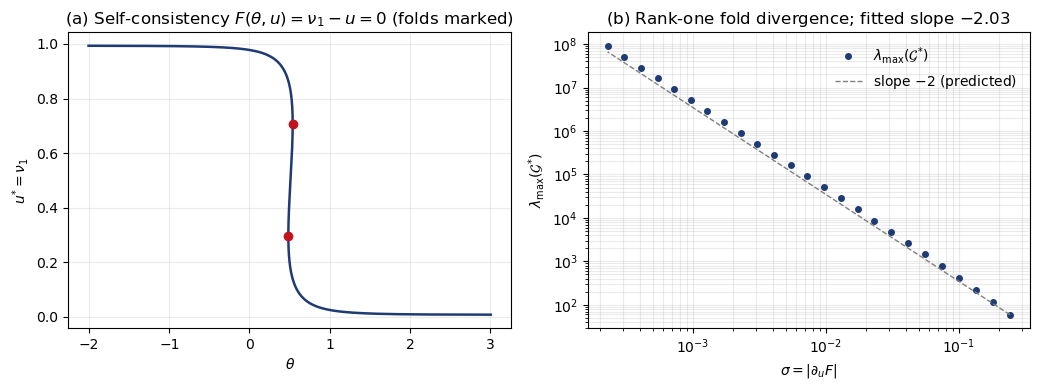

In [11]:
u_curve = np.array([alpha_response(Qmat(alpha0 * np.exp(g * varsigma(w))))[0][0] for w in wgrid])
theta_curve = u_curve - wgrid
sG = slope(sig, lamG)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.0))
ax1.plot(theta_curve, u_curve, "-", color="#1f3b73", lw=1.8)
for wf in folds:
    uf = alpha_response(Qmat(alpha0 * np.exp(g * varsigma(wf))))[0][0]
    ax1.plot(uf - wf, uf, "o", color="#c1121f", ms=6, zorder=5)
ax1.set_xlabel(r"$\theta$"); ax1.set_ylabel(r"$u^{*}=\nu_1$")
ax1.set_title(r"(a) Self-consistency $F(\theta,u)=\nu_1-u=0$ (folds marked)")
ax1.grid(alpha=0.25)

ax2.loglog(sig, lamG, "o", color="#1f3b73", ms=4, label=r"$\lambda_{\max}(\mathcal{G}^{*})$")
ax2.loglog(sig, lamG[0] * (sig / sig[0]) ** (-2.0), "--", color="gray", lw=1.0,
           label=r"slope $-2$ (predicted)")
ax2.set_xlabel(r"$\sigma=|\partial_u F|$"); ax2.set_ylabel(r"$\lambda_{\max}(\mathcal{G}^{*})$")
ax2.set_title(r"(b) Rank-one fold divergence; fitted slope $%.2f$" % sG)
ax2.legend(frameon=False); ax2.grid(alpha=0.25, which="both")
fig.tight_layout(); plt.show()

## §8 Concluding remarks: what is proved, and what is checked here

The notebook has verified, at the stated operating point of a reproducible family
(and in closed form where the paper does so), every identity displayed in this
notebook:

| result | identity | observed agreement |
|---|---|---|
| Theorem 2.3 | eigenpair relations; $\Lambda=\nu q$; positivity; normalizations | $\sim10^{-15}$ (machine precision) |
| Proposition 3.1 | $AR=RA=I-P$, $Rh=0$, $\nu R=0$, $RP=PR=0$ | $\sim10^{-16}$ |
| Theorem 4.1(a)-(d) | $\mathrm{d}P$, $\mathrm{d}\Lambda$, $\mathrm{d}\nu$, $\mathrm{d}h$ vs central differences | $\sim10^{-9}$-$10^{-10}$ |
| Proposition 4.4 | curvature of $\Lambda$ vs second differences | $\sim10^{-8}$ |
| Theorem 4.6, Remark 4.7 | $Q_0^{\#}=-Z$; $\mathrm{d}\pi=+\pi\,(\mathrm{d}Q)\,Z$; two-state closed form $-1/4$ | $\sim10^{-16}$, $\sim10^{-10}$, $\sim10^{-11}$ |
| Theorem 5.2 | $\mathcal G=J^{\top}\operatorname{diag}(1/\nu)J=\operatorname{Hess}D_{\mathrm{KL}}$ | $\sim10^{-9}$ |
| Proposition 7.2 | $\nu,h$ invariant; $\Lambda\mapsto s\Lambda$; $R\mapsto s^{-1}R$; channel split | $\sim10^{-15}$ |
| Theorem 6.4 / Example 7.4 | fold exponents $(-1,-1,-2)$ | fitted $\approx(-1.03,-1.03,-2.03)$ |

These agreements sit at the finite-difference floor anticipated by Remark 4.8
($\le10^{-8}$ first order, $\le10^{-7}$ second order), with the purely algebraic
identities at machine precision.

**What is proved, and where.** The algebraic layer -- the annihilation identities, the
response formulas of Theorem 4.1, the conservative-limit formulas with their sign, and
the channel split -- consists of theorems, machine-checked in the Lean package
accompanying the submission (`exposition/lean/`): the formalization takes the analytic
inputs (Perron-Frobenius simplicity, Kato differentiability, the constant-rank theorem,
and the fold normal form) as cited hypotheses and derives the closed-form identities
from them; `#print axioms` reports no `sorryAx`. The paper text itself does not
reference the formalization. The present notebook, like `verify_identities.py`,
supplies the independent *numerical* corroboration, and `figures/fold_example.py`
regenerates Figure 3 under a guardrail. By contrast, the stratification reading of
Remark 6.6 holds "under standard genericity hypotheses" and the small-noise exponents
of Remark 6.7 are "recorded for orientation" -- the paper does not claim them at the
rigor of §4, and neither does this notebook.

**Scope (§8.2).** The theory is stated with no application attached: it concerns the
principal spectral datum of essentially nonnegative matrices wherever such matrices
arise parametrically. The correspondence between this calculus and any particular
application -- including the compulsive-behaviors model in the parent repository, the
motivating example of the paper's §8.2 -- is a separate, empirical question. The Lean
build verifies the algebra; it does not verify that correspondence.

*To reproduce standalone:* `python verify_identities.py` and
`python figures/fold_example.py`, from this directory.